In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV # 튜닝

# Windows에서 사용자 폴더 이름에 한글(비-ASCII 문자)이 섞여 있으면, RandomizedSearchCV(n_jobs=-1) 같은
# joblib 병렬 처리가 임시 폴더 경로를 ASCII로 인코딩하려다 UnicodeEncodeError로 죽는다.
# ASCII로만 이루어진 시스템 임시 폴더를 대신 쓰도록 지정해 회피한다 (Windows 한정, 이미 설정돼 있으면 덮어쓰지 않음).
if os.name == "nt":
    os.environ.setdefault("JOBLIB_TEMP_FOLDER", os.path.join(os.environ.get("SystemRoot", r"C:\Windows"), "Temp"))

In [2]:
df = pd.read_csv('ai4i2020.csv')
df.columns = [c.strip() for c in df.columns]  # 원본 컬럼명에 앞뒤 공백이 섞여있음 (예: ' Product ID')
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [3]:
# Product ID 제거
df = df.drop(columns=["Product ID"])

# Type One-Hot Encoding
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

###################################################
# Feature Engineering
###################################################

# 출력
df["Power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]

# 온도차
df["Temp_diff"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)

# 출력 × 공구마모
df["Power_wear"] = (
    df["Power"] * df["Tool wear [min]"]
)

# 토크 / 회전속도
df["Torque_per_RPM"] = (
    df["Torque [Nm]"] /
    (df["Rotational speed [rpm]"] + 1)
)

# 공구 마모 * 토크
df["Torque_wear"] = (
    df["Torque [Nm]"] *
    df["Tool wear [min]"]
)
# 온도차 * 토크
df["Temp_Torque"] = (
    df["Temp_diff"] *
    df["Torque [Nm]"]
)
# 공정온도 / 회기온도
df["Temp_ratio"] = (
    df["Process temperature [K]"] /
    df["Air temperature [K]"]
)

###################################################
# X, y 분리
###################################################

X = df.drop(columns=[
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

y = df["Machine failure"]


param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [
        "balanced",
        {0:1, 1:3},
        {0:1, 1:5},
        {0:1, 1:8}
    ]
}



In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=49,
    stratify=y
)

In [5]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(
    X_train,
    y_train
)

In [7]:
rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="recall",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_sm, y_train_sm)

print("Best Parameters")
print(random_search.best_params_)

print()

print("Best Recall")
print(random_search.best_score_)





Best Parameters
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': {0: 1, 1: 8}}

Best Recall
0.9950836693084147


In [8]:
best_rf = random_search.best_estimator_

pred = best_rf.predict(X_test)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1932
           1       0.34      0.91      0.50        68

    accuracy                           0.94      2000
   macro avg       0.67      0.93      0.73      2000
weighted avg       0.97      0.94      0.95      2000



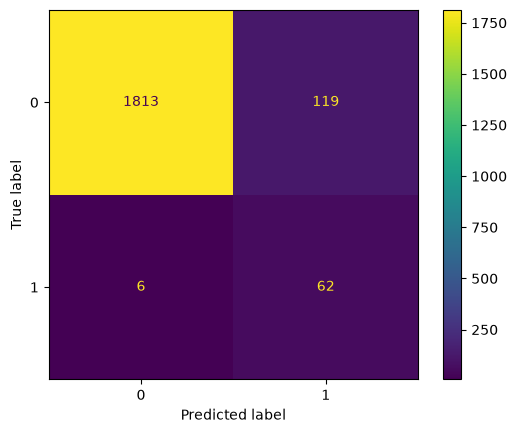

In [9]:
print(classification_report(y_test, pred))

ConfusionMatrixDisplay.from_predictions(y_test, pred)

plt.show()